<a href="https://colab.research.google.com/github/thesamokoosi/CodVeda-Data-Analytics-Internship/blob/main/Level3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## **Level 3 - Task 1: Predictive Modeling (Classification)**

**Objective:**  
Build a machine learning model to predict whether a customer will leave the service (**Churn**) based on their usage behavior and account details.

**Key Steps:**
1.  **Data Preprocessing:** Handle categorical variables and scale numerical features.
2.  **Model Training:** Use the `RandomForestClassifier` for robust classification.
3.  **Evaluation:** Use a Confusion Matrix and Classification Report to measure performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load the dataset
# Ensure 'churn-bigml-80.csv' is uploaded to your Colab session
df_churn = pd.read_csv('churn-bigml-80.csv')

# Display the first 5 rows to verify data
df_churn.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


### **1. Data Preprocessing**
*   **Encoding:** Converting categorical columns like 'State' and 'International plan' into numerical values.
*   **Feature Selection:** Dropping the target column 'Churn' from the features (X).
*   **Scaling:** Using `StandardScaler` to normalize numerical data for better model accuracy.

In [2]:
# Initialize LabelEncoder
le = LabelEncoder()

# Categorical columns to encode
categorical_cols = ['State', 'International plan', 'Voice mail plan', 'Churn']

for col in categorical_cols:
    df_churn[col] = le.fit_transform(df_churn[col])

# Define Features (X) and Target (y)
X = df_churn.drop('Churn', axis=1)
y = df_churn['Churn']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data Preprocessing and Scaling Complete.")

Data Preprocessing and Scaling Complete.


### **2. Model Training and Performance Evaluation**
We are using the **Random Forest Classifier**, an ensemble method that combines multiple decision trees to improve prediction accuracy and prevent overfitting.

Overall Model Accuracy: 95.13%

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       455
           1       1.00      0.67      0.80        79

    accuracy                           0.95       534
   macro avg       0.97      0.84      0.89       534
weighted avg       0.95      0.95      0.95       534



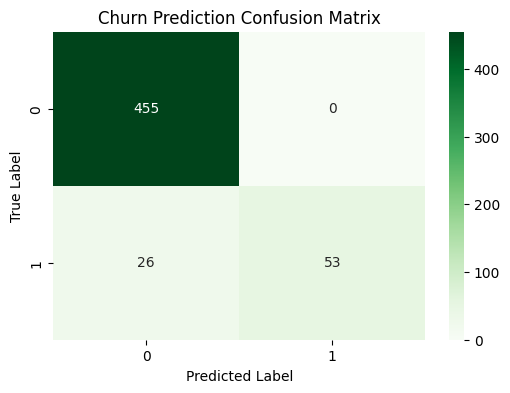

In [3]:
# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Print Accuracy and Classification Report
print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plotting the Confusion Matrix for visual clarity
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Churn Prediction Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Sentiment Analysis**
## **Level 3 - Task 3: NLP - Sentiment Analysis**

**Objective:**  
Analyze social media text data to classify the sentiment as **Positive, Negative, or Neutral**. We will also visualize the most frequent words using a WordCloud.

**Tools Used:**
*   `nltk`: For text cleaning and stopword removal.
*   `TextBlob`: For calculating sentiment polarity.
*   `WordCloud`: For visual representation of common terms.

In [7]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Download necessary NLTK components
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Load the Sentiment dataset
# Ensure 'Sentiment dataset.csv' is uploaded to your Colab session
df_sent = pd.read_csv('Sentiment dataset.csv')

# View data
df_sent.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,1/15/2023 12:30,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,1/15/2023 8:45,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,1/15/2023 15:45,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,1/15/2023 18:20,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,1/15/2023 19:55,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19


### **1. Text Cleaning & Tokenization**
We remove "noise" from the text, such as:
*   Converting to **lowercase**.
*   Removing **stopwords** (common words like 'the', 'is', 'a' that add no meaning).
*   Removing **punctuation**.

In [8]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        words = nltk.word_tokenize(text)
        # Filter out non-alphabetic words and stopwords
        cleaned = [w for w in words if w.isalpha() and w not in stop_words]
        return " ".join(cleaned)
    return ""

# Create a new column for cleaned text
df_sent['Cleaned_Text'] = df_sent['Text'].apply(clean_text)

# Calculate Sentiment Polarity (-1 to 1)
df_sent['Polarity'] = df_sent['Cleaned_Text'].apply(lambda x: TextBlob(x).sentiment.polarity)

print("Text Cleaning and Polarity Calculation Complete.")

Text Cleaning and Polarity Calculation Complete.


### **2. Visualizing Insights**
*   **Sentiment Distribution:** A bar chart showing the count of each sentiment category.
*   **WordCloud:** A visual representation of the most prominent words in the dataset.

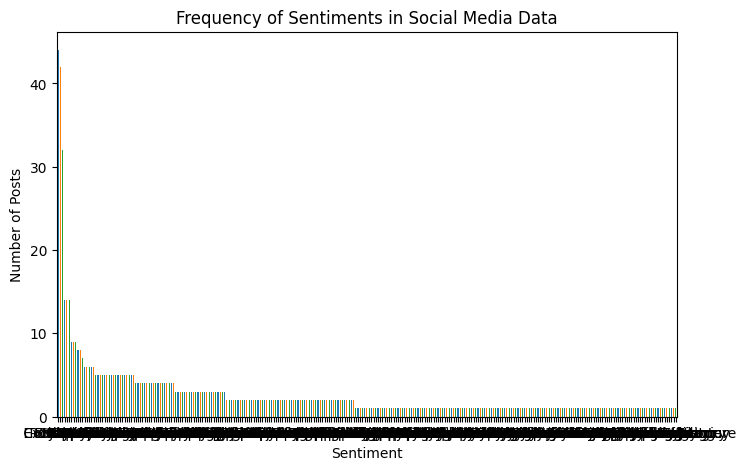

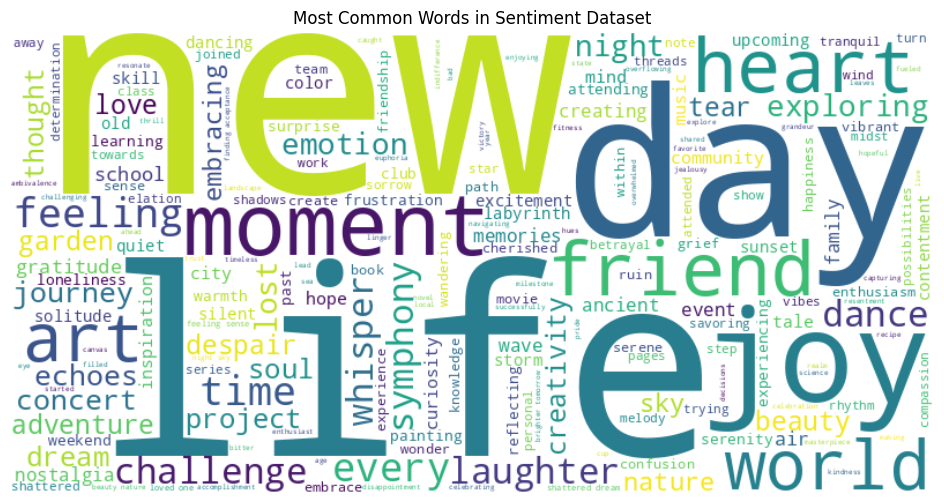

In [9]:
# 1. Visualize Sentiment counts (based on the original CSV 'Sentiment' column)
plt.figure(figsize=(8,5))
df_sent['Sentiment'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Frequency of Sentiments in Social Media Data')
plt.ylabel('Number of Posts')
plt.xticks(rotation=0)
plt.show()

# 2. Generate a WordCloud
text_corpus = " ".join(review for review in df_sent['Cleaned_Text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_corpus)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Sentiment Dataset')
plt.show()